In [ ]:
import os
import json
from google.cloud import bigquery
from typing import List, Dict, Tuple, Any, Optional
from IPython import get_ipython
from dbio.representative_db import connect_db, get_person_by_column
from requests import post, get
from dotenv import load_dotenv
from params.paths import DATA_DIR
import argparse
load_dotenv()

if get_ipython() is None:
	parser = argparse.ArgumentParser()
	parser.add_argument("--politician_name", type=str, default="田村智子")
	parser.add_argument("--youtube_channel_id", type=str, default="UC37tb1mDOEQyWKWkRa-zO8g")
	parser.add_argument("--twitter_user_id", type=str, default="2313532081")
	parser.add_argument("--topic_of_interest", type=str, default="防衛")
	parser.add_argument("--embedding_model", type=str, default="sbintuitions/sarashina-embedding-v2-1b")
	parser.add_argument("--subtopic_of_interest", type=str, default="防衛予算の増額")
	parser.add_argument("--local_llm_port", type=str, default="http://192.168.56.1:1234")
	parser.add_argument("--llm_model", type=str, default="openai/gpt-oss-20b")

	args = parser.parse_args()
	POLITICIAN_NAME = args.politician_name
	YOUTUBE_CHANNEL_ID = args.youtube_channel_id
	TWITTER_USER_ID = args.twitter_user_id
	TOPIC_OF_INTEREST = args.topic_of_interest
	EMBEDDING_MODEL = args.embedding_model
	LOCAL_LLM_PORT = args.local_llm_port
	SUBTOPIC_OF_INTEREST = args.subtopic_of_interest
	LLM_MODEL = args.llm_model
else: 
	POLITICIAN_NAME = "田村智子"
	YOUTUBE_CHANNEL_ID = "UC37tb1mDOEQyWKWkRa-zO8g"
	TWITTER_USER_ID = "2313532081"
	TOPIC_OF_INTEREST = "防衛"
	EMBEDDING_MODEL = "sbintuitions/sarashina-embedding-v2-1b"
	LOCAL_LLM_PORT = "http://192.168.56.1:1234"
	LLM_MODEL = "openai/gpt-oss-20b"
COMPLETION_ENDPOINT = f"{LOCAL_LLM_PORT}/v1/chat/completions"


print("Processing", POLITICIAN_NAME, "on youtube", YOUTUBE_CHANNEL_ID, "and twitter", TWITTER_USER_ID)
SKIP_PLATFORMS = []
if not YOUTUBE_CHANNEL_ID:
	SKIP_PLATFORMS.append("youtube")
if not TWITTER_USER_ID:
	SKIP_PLATFORMS.append("twitter")

conn = connect_db(
	dbname="kokkaidoc",
	user="postgres",
	password=os.getenv("PSQL_DATABASE_PASSWORD"),
	host="localhost",
	port="5432"
)
with conn.cursor() as cur:
	db_rows = get_person_by_column(cur, 'name_kanji', POLITICIAN_NAME)
POLITICIAN_ID = db_rows[0].person_id
# tamaki
# YOUTUBE_CHANNEL_ID = "UCLJNZ7osIjNix4bbkM-rj5w"
# edano
# YOUTUBE_CHANNEL_ID = "UC--p4szEtFbOQnmItCHO17A"
# tamura

# tamaki
# TWITTER_USER_ID = "96785342"
# edano
# TWITTER_USER_ID = "894816050205794304"
# tamura
client = bigquery.Client()

RELEVANCE_DATA_DIR = os.path.join(DATA_DIR, "tmp_idea_analysis", POLITICIAN_NAME)

YOUTUBE_DATA_OUTPUT_DIR = os.path.join(RELEVANCE_DATA_DIR, "youtube_data")
TWITTER_DATA_OUTPUT_DIR = os.path.join(RELEVANCE_DATA_DIR, "twitter_data")
PARLIAMENT_DATA_OUTPUT_DIR = os.path.join(RELEVANCE_DATA_DIR, "parliament_data")
for d in [YOUTUBE_DATA_OUTPUT_DIR, TWITTER_DATA_OUTPUT_DIR, PARLIAMENT_DATA_OUTPUT_DIR]:
	os.makedirs(d, exist_ok=True)
	
PARLIAMENT_DATA_DIR = os.path.join(DATA_DIR, "repr_speeches_id_organized", str(POLITICIAN_ID))
representative_parliament_speech_exists = os.path.exists(PARLIAMENT_DATA_DIR)
if not representative_parliament_speech_exists:
	raise ValueError(f"Representative parliament speech data for {POLITICIAN_NAME} does not exist")



Processing 田村智子 on youtube UC37tb1mDOEQyWKWkRa-zO8g and twitter 2313532081


## [Data collection] - Scripts

In [ ]:
YOUTUBE_META_QUERY = lambda channel_id : f"""
SELECT *
FROM `idea-a.jpdiet.videos` AS p
WHERE p.channel_id LIKE "%{channel_id}%"
"""

TWITTER_QUERY = lambda user_id : f"""
SELECT * FROM `idea-a.jpdiet.xdata_parsed`  as p
WHERE p.user_id_str LIKE "%{user_id}%"
"""

def get_all_videos_with_ids(video_ids:List[str]):
	query = """
	SELECT * 
	FROM `idea-a.jpdiet.transcripts` as p
	WHERE p.video_id in UNNEST(@video_ids)
	"""

	job_config = bigquery.QueryJobConfig(
		query_parameters=[
			bigquery.ArrayQueryParameter(
				"video_ids",
				"STRING",
				video_ids
			)
		]
	)
	for row in client.query(query, job_config=job_config):
		yield row
	

def save_all_data_for_query(query, output_path, datetime_format="%Y-%m-%d %H:%M:%S", datetime_columns=[]):
	print(query)
	query_job = client.query(query)

	with open(output_path, "w", encoding="utf-8") as f:
		for row in query_job:
			row_dict = dict(row.items())  # <-- convert Row → dict
			for col in datetime_columns:
				if col in row_dict:
					row_dict[col] = row_dict[col].strftime(datetime_format)
			
			json_line = json.dumps(row_dict, ensure_ascii=False)
			f.write(json_line + "\n")

def get_all_video_ids(path):
	video_ids = []
	with open(path, "r", encoding="utf-8") as f:
		for line in f:
			video_id = json.loads(line)["video_id"]
			video_ids.append(video_id)
	return video_ids

## [Data collection] mains

### Youtube

In [ ]:
## first get all the video ids
if os.path.exists(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl")) or not YOUTUBE_CHANNEL_ID:
	print("Youtube video meta already collected")
else:
	print("Collecting youtube data")
	save_all_data_for_query(YOUTUBE_META_QUERY(YOUTUBE_CHANNEL_ID), os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl"))
	video_ids = get_all_video_ids(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl"))

	with open(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts.jsonl"), "w", encoding="utf-8") as f:
		for row in get_all_videos_with_ids(video_ids):
			row_dict = dict(row.items())
			row_dict["created_at"] = row_dict["created_at"].strftime("%Y-%m-%d %H:%M:%S")
			row_dict["modified_at"] = row_dict["modified_at"].strftime("%Y-%m-%d %H:%M:%S")
			json_line = json.dumps(row_dict, ensure_ascii=False)
			f.write(json_line + "\n")

### Twitter

In [ ]:
if os.path.exists(os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl")) or not TWITTER_USER_ID:
	print("Twitter data already collected or twitter user id is not provided")
else:
	print("Collecting twitter data")
	save_all_data_for_query(TWITTER_QUERY(TWITTER_USER_ID), os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl"), datetime_columns=['created_at_ts', 'user_created_at_ts'])

## Statistics - Scripts

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from datetime import datetime
def get_number_of_lines_in_file(file_path):
	with open(file_path, "r", encoding="utf-8") as f:
		return sum(1 for _ in f)

# print("Parliament", get_number_of_lines_in_file(os.path.join(PARLIAMENT_DATA_DIR, "all_speeches.jsonl")))

creation_columns = {
	"youtube": ["published_at"],
	"twitter": ["created_at_ts"],
	"parliament": ["meta", "date"]
}

creation_formats = {
	"youtube": "%Y-%m-%dT%H:%M:%SZ",
	"twitter": "%Y-%m-%d %H:%M:%S",
	"parliament": "%Y-%m-%d"
}

def group_data_by_time(path, creation_columns, creation_format)-> Counter:
	counter = Counter()
	with open(path, "r", encoding="utf-8") as f:
		for line in f:
			data = json.loads(line)
			creation_time = data

			for col in creation_columns:
				creation_time = creation_time.get(col, None)
			creation_time = datetime.strptime(creation_time, creation_format)
			year = creation_time.year
			counter[year] += 1
			
	return counter

def plot_counter(counter:Counter):
	plt.bar(counter.keys(), counter.values())
	plt.show()

if False:
	youtube_counter = group_data_by_time(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl"), creation_columns["youtube"], creation_formats["youtube"])
	print("Youtube", get_number_of_lines_in_file(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl")))
	plot_counter(youtube_counter)
	print("Twitter", get_number_of_lines_in_file(os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl")))

	twitter_counter = group_data_by_time(os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl"), creation_columns["twitter"], creation_formats["twitter"])
	plot_counter(twitter_counter)
	parliament_counter = group_data_by_time(os.path.join(PARLIAMENT_DATA_DIR, "all_speeches.jsonl"), creation_columns["parliament"], creation_formats["parliament"])
	plot_counter(parliament_counter)



## [Filtering]Use the LLM to filter the data

In [ ]:
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from peft import PeftConfig, PeftModel
import random
try:
	from peft import AutoPeftModelForSequenceClassification
	_HAS_AUTO_PEFT_MODEL = True
	print("has auto peft")
except:
	from peft import AutoModelForSequenceClassification
	print("no auto peft model")
	_HAS_AUTO_PEFT_MODEL = False

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


PARLIAMENT_SPEECH_LABELS = [
	"質問文",
	"追及・確認文",
	"答弁文",
	"反論・再反論文",
	"意見文",
	"要望・提案文",
	"批判文",
	"評価文",
	"説明文",
	"事実文",
	"謝罪・釈明文",
	"手続・運営文",
	"その他"
]
class LLMFilter:
	def __init__(self, model_name:str):
		self.model_name = model_name
		self.model_cfg = AutoConfig.from_pretrained(model_name)
		self.device="cuda" if torch.cuda.is_available() else "cpu"

		self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
		self.model = AutoModelForSequenceClassification.from_pretrained(model_name).to(self.device).eval()
		print("Running on", self.device)


	def id2label(self):
		return self.model_cfg.id2label

	def label2id(self):
		return self.model_cfg.label2id

	@torch.no_grad()
	def predict(self, texts:list[str]):
		inputs = self.tokenizer(
			texts, 
			return_tensors="pt",
			truncation=True,
			padding=True
		).to(self.device)

		logits = self.model(**inputs).logits
		probs = torch.softmax(logits, dim=-1)

		probs_np = probs.cpu().numpy()
		preds = probs.argmax(dim=-1).cpu().numpy()
		out = []
		for i, t in enumerate(texts):
			pred = preds[i]
			prob = probs_np[i]
			out.append({
				"label": self.model_cfg.id2label[pred],
				"probs": prob.tolist(),
			})
		return out

class LLMFilterPeft:
	def __init__(self, model_name:str):
		self.model_name = model_name
		self.device="cuda" if torch.cuda.is_available() else "cpu"	
		self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
		self.model, self.model_cfg, self.base_name = self._load_model()
		print("Running on", self.device)
		

		self.model.to(self.device)


	def id2label(self):
		return self.model_cfg.id2label

	def label2id(self):
		return self.model_cfg.label2id

	def _load_model(self):
		peft_cfg = PeftConfig.from_pretrained(self.model_name)
		base_name = getattr(peft_cfg, "base_model_name_or_path", None)

		base_model = AutoModelForSequenceClassification.from_pretrained(
			base_name,
			trust_remote_code=False,
			num_labels=13
		)

		model = PeftModel.from_pretrained(
			base_model,
			self.model_name,
		)

		id2label = {i: label for i, label in enumerate(PARLIAMENT_SPEECH_LABELS)}
		label2id = {label: i for i, label in enumerate(PARLIAMENT_SPEECH_LABELS)}


		# The "real" classification config is usually on the base model
		model_cfg = base_model.config

		model_cfg.problem_type = "multi_label_classification"
		model_cfg.id2label = id2label
		model_cfg.label2id = label2id
		model_cfg.num_labels = len(id2label)


		return model, model_cfg, base_name

	@torch.no_grad()
	def predict(self, texts:list[str], threshold:float=0.5, top_k:int=2):
		inputs = self.tokenizer(
			texts,
			return_tensors="pt",
			truncation=True,
			padding=True,
		).to(self.device)

		logits = self.model(**inputs).logits 
		probs = torch.sigmoid(logits).cpu().numpy()

		out = []
		for i, t in enumerate(texts):
			row = probs[i]
			chosen = [self.model_cfg.id2label[j] for j, p in enumerate(row) if float(p) >= threshold]
			if len(chosen) == 0:
				chosen = ["その他"]
			top_ids = row.argsort()[-top_k:][::-1]
			top = [(self.model_cfg.id2label[int(j)], float(row[int(j)])) for j in top_ids]
			out.append({
				"labels(threshold)": chosen,
				"topk": top,
				"probs": row.tolist(),
			})
		return out

		
		
			

### [Filtering]Twitter filtering

In [ ]:
if os.path.exists(os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data_filtered.jsonl")) or not TWITTER_USER_ID:
	print("Twitter data already filtered or twitter user id is not provided")
else:
	twitter_llm_filter = LLMFilter(
		model_name="kkatodus/text_labeller_twitter-full-deberta-v3-base-japanese",
	)
	data_path = os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl")
	filtered_data_path = os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data_filtered.jsonl")
	with open(data_path, "r", encoding="utf-8") as f, open(filtered_data_path, "w", encoding="utf-8") as f_filtered:
		for line in f:
			data = json.loads(line)
			text = data["text"]
			if not text:
				continue
			pred = twitter_llm_filter.predict([text])
			if pred[0]["label"] == "その他":
				continue
			data["label"] = pred[0]["label"]
			f_filtered.write(json.dumps(data, ensure_ascii=False) + "\n")

# print(twitter_llm_filter.id2label())

# print(twitter_llm_filter.predict(["社会保障改革は凄く重要です", '暇だな']))

# print("Youtube", get_number_of_lines_in_file(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl")))
# print("Twitter", get_number_of_lines_in_file(os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data.jsonl")))
# print("Parliament", get_number_of_lines_in_file(os.path.join(PARLIAMENT_DATA_DIR, "all_speeches.jsonl")))




### [Filtering] Youtube filtering

In [ ]:
import re
from tqdm import tqdm
if os.path.exists(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered.jsonl")) or not YOUTUBE_CHANNEL_ID:
	print("Youtube transcripts already filtered or youtube channel id is not provided")
else:

	print("Filtering Youtube transcripts")
	data_path = os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts.jsonl")

	filtered_data_path = os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered.jsonl")

	youtube_filter_llm = LLMFilter(
		model_name="kkatodus/text_labeller_youtube-full-deberta-v3-base-japanese",
	)


	print("Youtube filter llm loaded")
	def add_periods(text: str) -> str:
		"""Insert Japanese periods after sentence-ending phrases.

		- Adds "。" after any occurrence of the end words.
		- Does NOT add if it's already followed by punctuation like "。", "！", "？".
		"""
		end_words = ["ですね", "ですよ", "である", "です", "ます", "だよ", "でしょうか","ください", "しれません", "しましょう"]
		pattern = "(" + "|".join(re.escape(w) for w in end_words) + ")"
		# Replace end-word occurrences not already followed by punctuation.
		return re.sub(pattern + r"(?![。！？!?])", r"\1。", text)


	with open(data_path, "r", encoding="utf-8") as f, open(filtered_data_path, "w", encoding="utf-8") as f_filtered:
		print("Starting filtering")

		batch = []
		batch_video_ids = []
		for line in tqdm(f):
		

			while len(batch) > 20:
				pred = youtube_filter_llm.predict(batch[:20])
				for p, b, vid in zip(pred, batch[:20], batch_video_ids[:20]):
					if p["label"] == "その他":
						continue
					out_dict = {}
					out_dict["label"] = p["label"]
					out_dict["video_id"] = vid
					out_dict["text"] = b
					f_filtered.write(json.dumps(out_dict, ensure_ascii=False) + "\n")
				batch = batch[20:]
				batch_video_ids = batch_video_ids[20:]
			data = json.loads(line)
			print("Processing line", data["video_id"])
			video_id = data["video_id"]
			text = data["text"]
			if not text:
				continue
			text = add_periods(text)
			split_text = text.split("。")
			for t in split_text:
				if not t or len(t) < 10:
					continue
				else:
					batch.append(t)
					batch_video_ids.append(video_id)

		if len(batch) > 0:
			pred = youtube_filter_llm.predict(batch)
			for p, b, vid in zip(pred, batch, batch_video_ids):
				if p["label"] == "その他":
					continue
				out_dict = {}
				out_dict["label"] = p["label"]
				out_dict["video_id"] = vid
				out_dict["text"] = b
				f_filtered.write(json.dumps(out_dict, ensure_ascii=False) + "\n")

if os.path.exists(os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered_with_date.jsonl")) or not YOUTUBE_CHANNEL_ID:
	print("[Filtering]Youtube transcripts already filtered with date or youtube channel id is not provided")

else:

	# creating a filtered file with the date
	filtered_data_path = os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered.jsonl")
	meta_data_path = os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_video_meta.jsonl")
	filtered_data_path_with_date = os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered_with_date.jsonl")
	# create video_id to date mapping
	video_id_to_date = {}
	with open(meta_data_path, "r", encoding="utf-8") as f:
		for line in f:
			data = json.loads(line)
			video_id_to_date[data["video_id"]] = data["published_at"]

	print(video_id_to_date)
	with open(filtered_data_path, "r", encoding="utf-8") as f, open(filtered_data_path_with_date, "w", encoding="utf-8") as f_filtered:
		for line in f:
			data = json.loads(line)
			data["date"] = video_id_to_date[data["video_id"]]
			f_filtered.write(json.dumps(data, ensure_ascii=False) + "\n")



## [Filtering] Parliament filtering

In [ ]:
if os.path.exists(os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, "parliament_transcripts_filtered.jsonl")) or not PARLIAMENT_DATA_DIR:
	print("[Filtering]Parliament speeches already filtered or parliament data directory is not provided")
else:
	BATCH_SIZE = 20
	THRESHOLD = 0.35
	print("Filtering Parliament speeches")

	parliament_llm_filter = LLMFilterPeft(
		model_name="kkatodus/text_labeller_parliament-deberta-v3-base-japanese",
	)
	data_path = os.path.join(PARLIAMENT_DATA_DIR, "all_speeches.jsonl")

	filtered_data_path = os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, "parliament_transcripts_filtered.jsonl")

	with open(data_path, "r", encoding="utf-8") as f, open(filtered_data_path, "w", encoding="utf-8") as f_filtered:
		batch = []
		for line in tqdm(f):
			while len(batch) > BATCH_SIZE:
				pred = parliament_llm_filter.predict([b['speech'] for b in batch[:BATCH_SIZE]], threshold=THRESHOLD)
				for p, b in zip(pred, batch[:BATCH_SIZE]):
					out_dict = {}
					out_dict["label"] = p["labels(threshold)"]
					out_dict["speech_id"] = b['speechID']
					out_dict["text"] = b['speech']
					out_dict["date"] = b['meta']['date']
					f_filtered.write(json.dumps(out_dict, ensure_ascii=False) + "\n")
				batch = batch[BATCH_SIZE:]
			data = json.loads(line)
			print("Processing line", data["speechID"])
			speech_id = data["speechID"]
			text = data["speech"]
			if not text:
				continue
			split_text = text.split("。")
			for t in split_text:
				if not t or len(t) < 10:
					continue
				else:
					batch.append({
						"speechID": speech_id,
						"speech": t,
						"meta": data["meta"]
					})
				
		if len(batch) > 0:
			pred = parliament_llm_filter.predict([b['speech'] for b in batch], threshold=THRESHOLD)
			for p, b, in zip(pred, batch):
				out_dict = {}
				out_dict["label"] = p["labels(threshold)"]
				out_dict["speech_id"] = b['speechID']
				out_dict["text"] = b['speech']
				out_dict["date"] = b['meta']['date']
				f_filtered.write(json.dumps(out_dict, ensure_ascii=False) + "\n")

## [Embeddings] Using LLMs to embed the data 

In [ ]:
from sentence_transformers import SentenceTransformer

EMBED_PLATFORMS = ["youtube", "twitter", "parliament"]
INPUT_PATHS = {
	"youtube": os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered_with_date.jsonl"),
	"twitter": os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data_filtered.jsonl"),
	"parliament": os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, "parliament_transcripts_filtered.jsonl"),
}

KEEP_LABELS = {
	"youtube": ["政治"],
	"twitter": ["政治"],
	"parliament":["質問文","追及・確認文","答弁文","反論・再反論文","意見文","要望・提案文","批判文","評価文","説明文","事実文"]
}

KEEP_COLUMNS = {
	"youtube": ["text", "date"],
	"twitter": ["text", "created_at_ts", "tweet_id"],
	"parliament": ["text", "date", "speech_id"]
}

OUTPUT_PATHS = {
	"youtube": os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered_with_date_embeddings.jsonl"),
	"twitter": os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data_filtered_embeddings.jsonl"),
	"parliament": os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, "parliament_transcripts_filtered_embeddings.jsonl")
}

embed_model = SentenceTransformer(EMBEDDING_MODEL)


for platform in EMBED_PLATFORMS:
	if platform in SKIP_PLATFORMS:
		print(f"[Embedding] Skipping {platform} because it is in SKIP_PLATFORMS")
		continue

	input_path = INPUT_PATHS[platform]
	output_path = OUTPUT_PATHS[platform]
	if os.path.exists(output_path):
		print(f"[Embedding] {platform} embeddings already exist")
		continue
	print(f"[Embedding] {platform} data")

	keep_labels = KEEP_LABELS[platform]
	keep_columns = KEEP_COLUMNS[platform]

	with open(input_path, "r", encoding="utf-8") as f, open(output_path, "w", encoding="utf-8") as f_output:
		batch : List[Dict[str, Any]] = []
		for line in tqdm(f):
			if len(batch) > 20:
				pred = embed_model.encode([b["text"].strip() for b in batch])
				for p, b in zip(pred, batch):
					f_output.write(json.dumps(
						{col: b[col] for col in keep_columns} | {"embedding": p.tolist()},
						ensure_ascii=False) + "\n")
				batch = []
			data = json.loads(line)
			if platform == "parliament":
				if any(label in data["label"] for label in keep_labels):
					batch.append({
						col: data[col] for col in keep_columns
					})
			elif platform == "youtube" or platform == "twitter":
				if data["label"] in keep_labels:
					batch.append({
						col: data[col] for col in keep_columns
					})
		if len(batch) > 0:
			pred = embed_model.encode([b["text"].strip() for b in batch])
			for p, b in zip(pred, batch):
				f_output.write(json.dumps(
					{col: b[col] for col in keep_columns} | {"embedding": p.tolist()},
					ensure_ascii=False) + "\n")




## [Year grouping] And saving average

In [ ]:
from params.paths import ROOT_DIR
import os
import numpy as np
from datetime import datetime

embedded_data_paths = {
	"youtube": os.path.join(YOUTUBE_DATA_OUTPUT_DIR, "youtube_transcripts_filtered_with_date_embeddings.jsonl"),
	"twitter": os.path.join(TWITTER_DATA_OUTPUT_DIR, "twitter_data_filtered_embeddings.jsonl"),
	"parliament": os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, "parliament_transcripts_filtered_embeddings.jsonl")
}
platforms = [
	"youtube",
	"twitter",
	"parliament"
]

output_dirs = {
	"youtube": os.path.join(YOUTUBE_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST),
	"twitter": os.path.join(TWITTER_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST),
	"parliament": os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST)	
}

for output_dir in output_dirs.values():
	if not os.path.exists(output_dir):
		os.makedirs(output_dir, exist_ok=True)


creation_formats = {
	"youtube": "%Y-%m-%dT%H:%M:%SZ",
	"twitter": "%Y-%m-%d %H:%M:%S",
	"parliament": "%Y-%m-%d"
}

time_keys = {
	"youtube": "date",
	"twitter": "created_at_ts",
	"parliament": "date"
}


RESOURCE_DIR = os.path.join(ROOT_DIR, "resource")
experiment_config_path = os.path.join(RESOURCE_DIR, "experiment_config.json")

with open(experiment_config_path, "r", encoding="utf-8") as f:
	experiment_config = json.load(f)


def check_if_search_words_in_text(text: str, search_words: List[str]) -> bool:
	for word in search_words:
		if word in text:
			return True
	return False

def create_year_grouped_embedding_for_topic(topic: str, input_path: str, output_path: str, platform: str):

	year_grouped_embeddings = {}
	search_words = [d for d in experiment_config if d["topic_name"] == topic][0]["search_words"]
	with open(input_path, "r", encoding="utf-8") as f, open(output_path, "w", encoding="utf-8") as f_output:
		for line in f.readlines():
			data = json.loads(line)
			if not check_if_search_words_in_text(data["text"], search_words):
				continue
			creation_time = datetime.strptime(data[time_keys[platform]], creation_formats[platform])
			year = creation_time.year
			embedding = data["embedding"]
			if not int(year) in year_grouped_embeddings:
				year_grouped_embeddings[int(year)] = {"embeddings": np.array(embedding), "number_of_embeddings":1}
			else:
				year_grouped_embeddings[int(year)]["embeddings"] += np.array(embedding)
				year_grouped_embeddings[int(year)]["number_of_embeddings"]+= 1
		year_grouped_embeddings_averaged = {k: v["embeddings"]/float(v["number_of_embeddings"]) for k, v in year_grouped_embeddings.items()}
		for year, embedding in year_grouped_embeddings_averaged.items():
			f_output.write(json.dumps({"year": year, "number_of_embeddings": year_grouped_embeddings[year]["number_of_embeddings"], "embedding": list(embedding)}, ensure_ascii=False) + "\n")



for platform in platforms:
	if platform in SKIP_PLATFORMS:
		print(f"[Embedding] Skipping {platform} because it is in SKIP_PLATFORMS")
		continue
	output_path = os.path.join(output_dirs[platform], f"{TOPIC_OF_INTEREST}_year_grouped_embeddings.jsonl")
	if not os.path.exists(output_path):
		print(f"Creating year grouped embeddings for {TOPIC_OF_INTEREST} on {platform}")
		create_year_grouped_embedding_for_topic(TOPIC_OF_INTEREST, embedded_data_paths[platform], output_path, platform)
			

## [Quick visualization] Lets visualize the year grouped embeddings along with the axis examples

In [4]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import copy
from params.paths import ROOT_DIR

AXIS_EXAMPLES_PATH = os.path.join(ROOT_DIR, "axis", "防衛", "examples", "防衛予算の増額_example_speeches.json")

output_paths = {
	"youtube": os.path.join(YOUTUBE_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST,f"{TOPIC_OF_INTEREST}_year_grouped_embeddings.jsonl"),
	"twitter": os.path.join(TWITTER_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST, f"{TOPIC_OF_INTEREST}_year_grouped_embeddings.jsonl"),
	"parliament": os.path.join(PARLIAMENT_DATA_OUTPUT_DIR, TOPIC_OF_INTEREST, f"{TOPIC_OF_INTEREST}_year_grouped_embeddings.jsonl")
}
platform_cmap = {
	"youtube": "yellow",
	"twitter": "cyan",
	"parliament": "green",
	"pro": "red",
	"con": "blue"
}


def get_axis_examples_embeddings(embed_model: SentenceTransformer, 
								axis_example_path: str|None =AXIS_EXAMPLES_PATH):
	# get axis examples
	with open(axis_example_path, "r", encoding="utf-8") as f:
		axis_examples = json.load(f)
		pro_opinions = axis_examples["pro"]["opinions"]
		con_opinions = axis_examples["con"]["opinions"]
		pro_opinions_embeddings = embed_model.encode(pro_opinions)
		con_opinions_embeddings = embed_model.encode(con_opinions)
	return pro_opinions_embeddings, con_opinions_embeddings

def project_vectors_onto_axis_get_scalar_values(vectors: List[np.ndarray], axis_vector: np.ndarray):
	scalar_values = []
	for vector in vectors:
		scalar_values.append(np.dot(vector, axis_vector) / np.dot(axis_vector, axis_vector))
	return scalar_values


vectors = []
platform_and_years = []
c = []
if not os.path.exists(os.path.join(ROOT_DIR, "tmp", f"{POLITICIAN_NAME}_axis_examples_embeddings.png")):
	embed_model = SentenceTransformer("sbintuitions/sarashina-embedding-v2-1b")
	pro_opinions_embeddings, con_opinions_embeddings = get_axis_examples_embeddings(embed_model)

	pro_mean = np.mean(pro_opinions_embeddings, axis=0)
	con_mean = np.mean(con_opinions_embeddings, axis=0)
	
	for platform in platforms:
		if platform in SKIP_PLATFORMS:
			print(f"[Embedding] Skipping {platform} because it is in SKIP_PLATFORMS")
			continue
		with open(output_paths[platform], "r", encoding="utf-8") as f:
			for line in f:
				data = json.loads(line)
				if platform != "parliament":
					if data['number_of_embeddings'] < 5:
						continue
				vectors.append(data["embedding"])
				platform_and_years.append((platform, data['year']))
				c.append(platform_cmap[platform])


	
	umap_vectors = copy.deepcopy(vectors)
	umap_vectors.append(pro_mean)
	umap_vectors.append(con_mean)
	umap_labels = copy.deepcopy(platform_and_years)
	umap_labels.append(("pro", None))
	umap_labels.append(("con", None))
	umap_colors = copy.deepcopy(c)
	umap_colors.append(platform_cmap["pro"])
	umap_colors.append(platform_cmap["con"])
	
	fit = umap.UMAP(n_components=2, random_state=42).fit(umap_vectors)

	fig, ax = plt.subplots(2,1)
	ax[0].scatter(fit.embedding_[:, 0], fit.embedding_[:, 1], c=umap_colors)
	for i, label in enumerate(umap_labels):
		label_str = f"{label[0]} {label[1] if label[1] is not None else ''}"
		ax[0].annotate(
			label_str, 
			(fit.embedding_[i, 0], fit.embedding_[i, 1]),
			textcoords="offset points",
			xytext=(3,3),
			ha='left',
			fontsize=8,
			alpha=0.6
		)

	axis_vector = (pro_mean - con_mean).astype(np.float32)
	scalar_values = project_vectors_onto_axis_get_scalar_values(vectors, axis_vector)
	for platform in platforms:
		if platform in SKIP_PLATFORMS:
			print(f"[Embedding] Skipping {platform} because it is in SKIP_PLATFORMS")
			continue
		value_and_year = []
		for scalar_value, (plat, yr) in zip(scalar_values, platform_and_years):
			if plat == platform and yr is not None:
				value_and_year.append((yr, float(scalar_value)))


		value_and_year.sort(key=lambda x: x[0])
		if not value_and_year:
			continue
		
		years = [v[0] for v in value_and_year]
		values = [v[1] for v in value_and_year]

		ax[1].plot(years, values, label=platform, c=platform_cmap[platform])


	ax[1].set_xlabel("year")
	ax[1].set_ylabel("projection onto axis")
	ax[1].legend()
	plt.tight_layout()
	output_dir = os.path.join(ROOT_DIR, "tmp")
	os.makedirs(output_dir, exist_ok=True)
	plt.savefig(os.path.join(output_dir, f"{POLITICIAN_NAME}_{TOPIC_OF_INTEREST}_axis_examples_embeddings.png"))


/root/projects/kokkai_analysis/data/data_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

## Now lets put everyone one the same plot and see how their positions change over time

In [ ]:
from params.paths import DATA_DIR, ROOT_DIR
import os
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import copy
import numpy as np
from tqdm import tqdm
import japanize_matplotlib

platform_cmap = {
	"youtube": "darkred",
	"twitter": "cyan",
	"parliament": "green",
	"pro": "red",
	"con": "blue"
}
party2color = {
    '自民': 'black',
    '国民': 'blue',
    '立憲': 'orange',
    '公明': 'aqua',
    '共産': 'red',
    '維新': 'gold',
	'社民': 'brown',
	"pro": "red",
	"con": "blue"
}

name2party = {
	"枝野幸男": "国民",
	"石破茂": "自民",
	"木原稔" : "自民",
	"吉村洋文": "維新",
	"木原誠二": "自民",
	"田村智子": "共産",
	"斉藤鉄夫": "公明",
	"河野太郎": "自民",
	"福島瑞穂": "社民",
	"米山隆一": "立憲",
	"岡本三成": "公明",
	"小林鷹之": "自民",
	"玉木雄一郎": "国民",
	"小野田紀美": "自民",
	"小西洋之": "立憲",
}

AXIS_EXAMPLES_PATH = os.path.join(ROOT_DIR, "axis", TOPIC_OF_INTEREST, "examples", f"{SUBTOPIC_OF_INTEREST}_example_speeches.json")

def get_axis_examples_embeddings(embed_model: SentenceTransformer, 
								axis_example_path: str|None = AXIS_EXAMPLES_PATH):
	# get axis examples
	with open(axis_example_path, "r", encoding="utf-8") as f:
		axis_examples = json.load(f)
		pro_opinions = axis_examples["pro"]["opinions"]
		con_opinions = axis_examples["con"]["opinions"]
		pro_opinions_embeddings = embed_model.encode(pro_opinions)
		con_opinions_embeddings = embed_model.encode(con_opinions)
	return pro_opinions_embeddings, con_opinions_embeddings
def project_vectors_onto_axis_get_scalar_values(vectors: List[np.ndarray], axis_vector: np.ndarray):
	scalar_values = []
	for vector in vectors:
		scalar_values.append(np.dot(vector, axis_vector) / np.dot(axis_vector, axis_vector))
	return scalar_values

embeddings = []
platforms = []
politicians = []
parties = []
years = []
combined_str_identifier = []

print("Organizing data into the arrays")
for politician_name in tqdm(os.listdir(os.path.join(DATA_DIR, "tmp_idea_analysis"))):
	politician_dir = os.path.join(DATA_DIR, "tmp_idea_analysis", politician_name)
	for platform in os.listdir(politician_dir):
		platform_letter = platform[0]
		topic_group_embeddings_path = os.path.join(politician_dir, platform, TOPIC_OF_INTEREST, f"{TOPIC_OF_INTEREST}_year_grouped_embeddings.jsonl")
		if not os.path.exists(topic_group_embeddings_path):
			continue
		with open(topic_group_embeddings_path, "r", encoding="utf-8") as f:
			for line in f:
				data = json.loads(line)
				if data["number_of_embeddings"] < 5 and platform != "parliament":
					continue
				embeddings.append(data["embedding"])
				platforms.append(platform.split("_")[0])
				politicians.append(politician_name)
				parties.append(name2party[politician_name])
				years.append(data["year"])
				combined_str_identifier.append(f"{politician_name}_{platform_letter}_{data['year']}")

platform_colors = [platform_cmap[p] for p in platforms]
party_colors = [party2color[p] for p in parties]



MODEL_NAME = "sbintuitions/sarashina-embedding-v2-1b"

print("Loading embedding model")
embed_model = SentenceTransformer(MODEL_NAME)

print("Getting axis examples embeddings")
pro_opinions_embeddings, con_opinions_embeddings = get_axis_examples_embeddings(embed_model)

print("Getting mean embeddings")
pro_mean = np.mean(pro_opinions_embeddings, axis=0)
con_mean = np.mean(con_opinions_embeddings, axis=0)





print("Organizing umap vectors")
umap_vectors = copy.deepcopy(embeddings)
umap_vectors.append(pro_mean)
umap_vectors.append(con_mean)
umap_labels = copy.deepcopy(combined_str_identifier)
umap_labels.append(("pro", ""))
umap_labels.append(("con", ""))
umap_colors_platform = copy.deepcopy(platform_colors)
umap_colors_platform.append(platform_cmap["pro"])
umap_colors_platform.append(platform_cmap["con"])
umap_colors_party = copy.deepcopy(party_colors)
umap_colors_party.append(party2color["pro"])
umap_colors_party.append(party2color["con"])



Organizing data into the arrays


100%|██████████| 15/15 [00:00<00:00, 30.10it/s]


Loading embedding model
Getting axis examples embeddings
Getting mean embeddings
Organizing umap vectors


Fitting umap


/root/projects/kokkai_analysis/data/data_venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


plotting umap with platform as the colors
plotting umap with party as the colors
plotting time series with platform as the colors


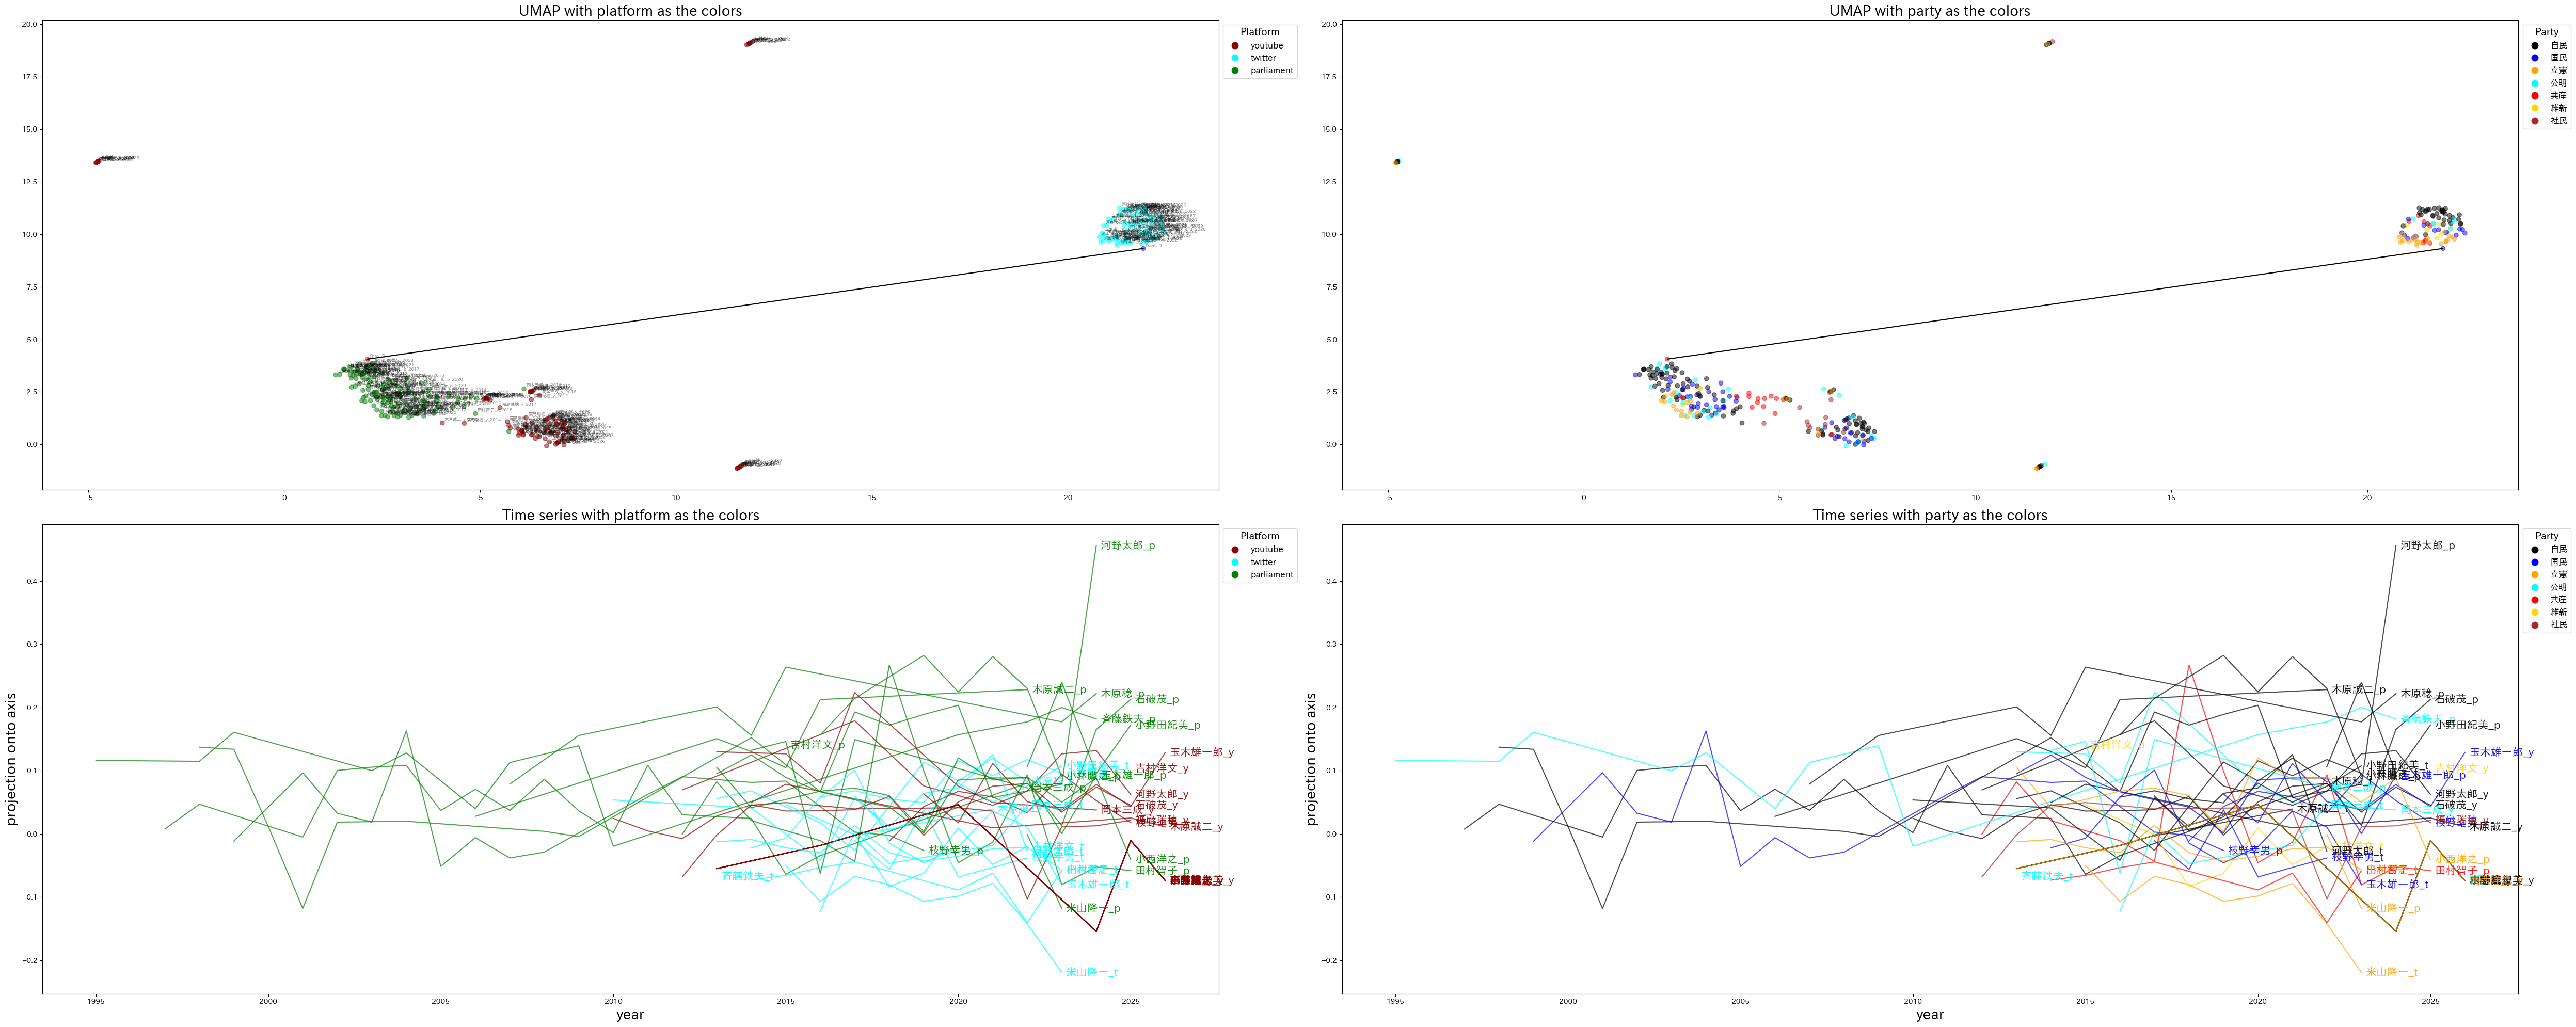

In [ ]:
from matplotlib.lines import Line2D
from datetime import datetime
print("Fitting umap")



ALPHA_LINES = 0.7
ALPHA_POINTS = 0.5
fit = umap.UMAP(n_components=2, random_state=42).fit(umap_vectors)
# plots, time series with platform as the colors, time series with party as the colors, umap with platform as the colors, umap with party as the colors
fig, ax = plt.subplots(2,2, figsize=(50,20))
print("plotting umap with platform as the colors")
ax[0,0].scatter(fit.embedding_[:, 0], fit.embedding_[:, 1], c=umap_colors_platform, alpha=ALPHA_POINTS)
pro_after_umap = fit.embedding_[-2]
con_after_umap = fit.embedding_[-1]

con_2_pro = con_after_umap - pro_after_umap
pro_further = con_after_umap + con_2_pro





for i, label in enumerate(umap_labels):
	
	ax[0,0].annotate(
		label, 
		(fit.embedding_[i, 0], fit.embedding_[i, 1]),
		textcoords="offset points",
		xytext=(3,3),
		ha='left',
		fontsize=6,
		alpha=0.5
	)

print("plotting umap with party as the colors")
ax[0,1].scatter(fit.embedding_[:, 0], fit.embedding_[:, 1], c=umap_colors_party, alpha=ALPHA_POINTS)

axis_vector = (pro_mean - con_mean).astype(np.float32)
scalar_values = project_vectors_onto_axis_get_scalar_values(embeddings, axis_vector)
last_y_vals = []
last_value_identifiers = []
print("plotting time series with platform as the colors")
for politician_name in os.listdir(os.path.join(DATA_DIR, "tmp_idea_analysis")):
	for plat in ["youtube", "twitter", "parliament"]:
		y_vals = []
		x_vals = []
		for s, yr, pl, pol in zip(scalar_values, years, platforms, politicians):
			if pl == plat and pol == politician_name:
				y_vals.append(s)
				x_vals.append(yr)
		if not y_vals:
			continue
		# sort x_vals and y_vals by x_vals
		x_vals, y_vals = zip(*sorted(zip(x_vals, y_vals)))
		ax[1, 0].plot(x_vals, y_vals, label=plat, c=platform_cmap[plat], alpha=ALPHA_LINES)
		ax[1, 1].plot(x_vals, y_vals, label=plat, c=party2color[name2party[politician_name]], alpha=ALPHA_LINES)

		# Annotate the last point of each series with an identifier (politician + platform)
		x_last, y_last = x_vals[-1], y_vals[-1]
		identifier = f"{politician_name}_{plat[0]}"
		ax[1, 0].annotate(
			identifier,
			(x_last, y_last),
			textcoords="offset points",
			xytext=(6, 0),
			ha="left",
			va="center",
			fontsize=15,
			alpha=0.9,
			color=platform_cmap[plat],
		)
		ax[1, 1].annotate(
			identifier,
			(x_last, y_last),
			textcoords="offset points",
			xytext=(6, 0),
			ha="left",
			va="center",
			fontsize=15,
			alpha=0.9,
			color=party2color[name2party[politician_name]],
		)

		last_y_vals.append(y_last)
		last_value_identifiers.append(identifier)

ax[0,0].plot([pro_after_umap[0], con_after_umap[0]], [pro_after_umap[1], con_after_umap[1]], c="black", alpha=1)
ax[0,1].plot([pro_after_umap[0], con_after_umap[0]], [pro_after_umap[1], con_after_umap[1]], c="black", alpha=1)

ax[0,0].set_title("UMAP with platform as the colors", fontsize=20)
ax[0,1].set_title("UMAP with party as the colors", fontsize=20)
ax[1, 0].set_title("Time series with platform as the colors", fontsize=20)
ax[1, 0].set_xlabel("year", fontsize=20)
ax[1, 0].set_ylabel("projection onto axis", fontsize=20)
ax[1, 1].set_title("Time series with party as the colors", fontsize=20)
ax[1, 1].set_xlabel("year", fontsize=20)
ax[1, 1].set_ylabel("projection onto axis", fontsize=20)




def _color_legend_handles(color_map, keys):
	return [
		Line2D(
			[0],
			[0],
			marker="o",
			linestyle="None",
			markersize=10,
			markerfacecolor=color_map[k],
			markeredgecolor="none",
			label=str(k),
		)
		for k in keys
		if k in color_map
	]

party_keys = [k for k in party2color.keys() if k not in {"pro", "con"}]
platform_keys = [k for k in platform_cmap.keys() if k in {"youtube", "twitter", "parliament"}]

ax[0, 0].legend(
	handles=_color_legend_handles(platform_cmap, platform_keys),
	title="Platform",
	fontsize=12,
	title_fontsize=14,
	loc="upper left",
	bbox_to_anchor=(1, 1),
)
ax[0, 1].legend(
	handles=_color_legend_handles(party2color, party_keys),
	title="Party",
	fontsize=12,
	title_fontsize=14,
	loc="upper left",
	bbox_to_anchor=(1, 1),
)

ax[1, 0].legend(
	handles=_color_legend_handles(platform_cmap, platform_keys),
	title="Platform",
	fontsize=12,
	title_fontsize=14,
	loc="upper left",
	bbox_to_anchor=(1, 1),
)
ax[1, 1].legend(
	handles=_color_legend_handles(party2color, party_keys),
	title="Party",
	fontsize=12,
	title_fontsize=14,
	loc="upper left",
	bbox_to_anchor=(1, 1),
)

plt.tight_layout()
output_dir = os.path.join(ROOT_DIR, "tmp")
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, f"{datetime.now().strftime('%Y%m%d')}_final_visualization.png"))





## Create a summary of the politician platform for each year, for each platform

In [ ]:
from params.paths import ROOT_DIR, DATA_DIR
import os
from requests import get

RESULTS_DIR = os.path.join(DATA_DIR, "tmp_idea_analysis")


def prompt_local_llm(prompt:str, system_prompt:str)->None:
	payload = json.dumps({
		"model": LLM_MODEL,
		"messages": [
			{
			"role": "system",
			"content": system_prompt
			},
			{
			"role": "user",
			"content": prompt
			}
		],
		"temperature": 0,
		"max_tokens": -1,
		"stream": False
	})
	headers = {
		'Content-Type': 'application/json'
		}
	print(f"PROMPTING LLM WITH \n{system_prompt}\n\n{prompt}")
	response = post(COMPLETION_ENDPOINT, headers=headers, data=payload)
	res_json = json.loads(response.text)
	print(f"GOT REPLY FROM LLM: \n {str(res_json)}")

	return res_json


for politician in os.listdir(RESULTS_DIR):
	politician_dir = os.path.join(RESULTS_DIR, politician)
	print(politician_dir)
			


/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/枝野幸男
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/石破茂
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/吉村洋文
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/木原誠二
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/田村智子
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/斉藤鉄夫
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/木原稔
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/河野太郎
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/福島瑞穂
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/米山隆一
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/岡本三成
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/小林鷹之
/root/projects/kokkai_analysis/data/params/../data/tmp_idea_analysis/玉木雄一郎
/root/projects/kokkai_analysis/data/par